In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# general purpose libraries

from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from matplotlib.font_manager import FontProperties
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE 
from sklearn.preprocessing import LabelEncoder

In [5]:
path_real_data = r"..\..\Data\9.Split-data for revision\Train_80\Parquet\\"

In [6]:
print("started...")
start_time = datetime.now()
num_samples = 1000000

# Read Parquet files
data_tomato_healthy = pd.read_parquet(path_real_data + "tomato_healthy.parquet", engine='pyarrow')[:num_samples]
data_tomato_unhealthy = pd.read_parquet(path_real_data + "tomato_unhealthy.parquet", engine='pyarrow')[:num_samples]
data_potato = pd.read_parquet(path_real_data + "potato.parquet", engine='pyarrow')[:num_samples]
data_chilli = pd.read_parquet(path_real_data + "chilli.parquet", engine='pyarrow').sample(frac=1)[:num_samples]
data_capsicum = pd.read_parquet(path_real_data + "capsicum.parquet", engine='pyarrow').sample(frac=1)[:num_samples]
data_mulberry = pd.read_parquet(path_real_data + "mulberry.parquet", engine='pyarrow').sample(frac=1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

# Data shapes
print("tomato_healthy:", data_tomato_healthy.shape)
print("tomato_unhealthy:", data_tomato_unhealthy.shape)
print("data_potato:", data_potato.shape)
print("chilli:", data_chilli.shape)
print("capsicum:", data_capsicum.shape)
print("mulberry:", data_mulberry.shape)

started...
Data loading time is:> 0:00:01.289055
tomato_healthy: (2138, 944)
tomato_unhealthy: (119, 944)
data_potato: (616, 944)
chilli: (100, 944)
capsicum: (60, 944)
mulberry: (120, 944)


In [7]:
# Data Concatenating
df = pd.concat([data_tomato_healthy, data_tomato_unhealthy, data_potato, data_chilli, data_capsicum, data_mulberry], axis = 0)
df_final=df.copy()
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,tomato_healthy,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,tomato_healthy,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,tomato_healthy,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,tomato_healthy,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,mulberry,0.288911,0.287745,0.282805,0.279601,0.292344,0.289934,0.284380,0.291108,0.287814,...,0.545138,0.543676,0.543734,0.546539,0.546735,0.544812,0.545571,0.548387,0.547967,0.546383
70,mulberry,0.169331,0.162138,0.161123,0.171299,0.165315,0.160561,0.160175,0.162686,0.164410,...,0.379804,0.381542,0.380640,0.376999,0.376167,0.376982,0.376163,0.374367,0.375158,0.377342
107,mulberry,0.059008,0.055769,0.054637,0.057774,0.062624,0.061473,0.059222,0.061246,0.059215,...,0.504251,0.501569,0.498377,0.497275,0.495185,0.488285,0.486758,0.492471,0.491235,0.485923
61,mulberry,0.055450,0.053371,0.054486,0.058525,0.056945,0.052089,0.050223,0.055132,0.057515,...,0.479896,0.478486,0.476875,0.477088,0.475024,0.470653,0.468824,0.467153,0.465836,0.467254


In [8]:
# Adding dummy class samples in df

dummy_df = df_final.loc[df_final['label']=='tomato_healthy']
dummy_df = pd.concat([dummy_df, dummy_df], ignore_index=True) # doubling the df
dummy_df['label'] = 'zummy'
dummy_df = dummy_df.head(3672)

df_final = pd.concat([df_final, dummy_df], ignore_index=True) # doubling the df
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,tomato_healthy,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,tomato_healthy,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,tomato_healthy,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,tomato_healthy,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6820,zummy,0.056081,0.052691,0.051201,0.052921,0.051997,0.057097,0.061098,0.057186,0.056909,...,0.471524,0.467629,0.465384,0.461803,0.459312,0.459162,0.458067,0.455035,0.453808,0.455869
6821,zummy,0.048163,0.054170,0.059828,0.061424,0.060181,0.059028,0.058245,0.058094,0.062767,...,0.464959,0.461359,0.459250,0.458484,0.456810,0.454960,0.453148,0.450342,0.448766,0.448053
6822,zummy,0.060535,0.057681,0.059155,0.062156,0.056995,0.058057,0.063021,0.066011,0.066569,...,0.481685,0.479979,0.477516,0.475209,0.473914,0.472998,0.470828,0.468638,0.467381,0.464156
6823,zummy,0.048570,0.051756,0.053030,0.052696,0.050216,0.047460,0.043285,0.038604,0.045873,...,0.452903,0.449835,0.447598,0.446153,0.444617,0.442495,0.441331,0.441898,0.440606,0.437796


In [9]:
# visulization class distribution

def freq_visualize(df, title, xlim=3000):
    print(df['label'].value_counts())
    labels = df['label'].values
    counter = Counter(labels) # counter object
    counter = dict(sorted(counter.items())) # converting counter obj. into dictionary
    x = list(counter.keys())
    y = list(counter.values())
    plt.rcParams.update({'font.size':8})
    fig = plt.figure(num=None, figsize=(10, 4), dpi=200, facecolor='w', edgecolor='red')
    plt.barh(x, y)
    plt.xlim(0, xlim)
    plt.ylabel("Labels", weight ='bold')
    plt.xlabel("Frequencies", weight ='bold')
    plt.title(title)
    plt.show()

zummy               3672
tomato_healthy      2138
potato               616
mulberry             120
tomato_unhealthy     119
chilli               100
capsicum              60
Name: label, dtype: int64


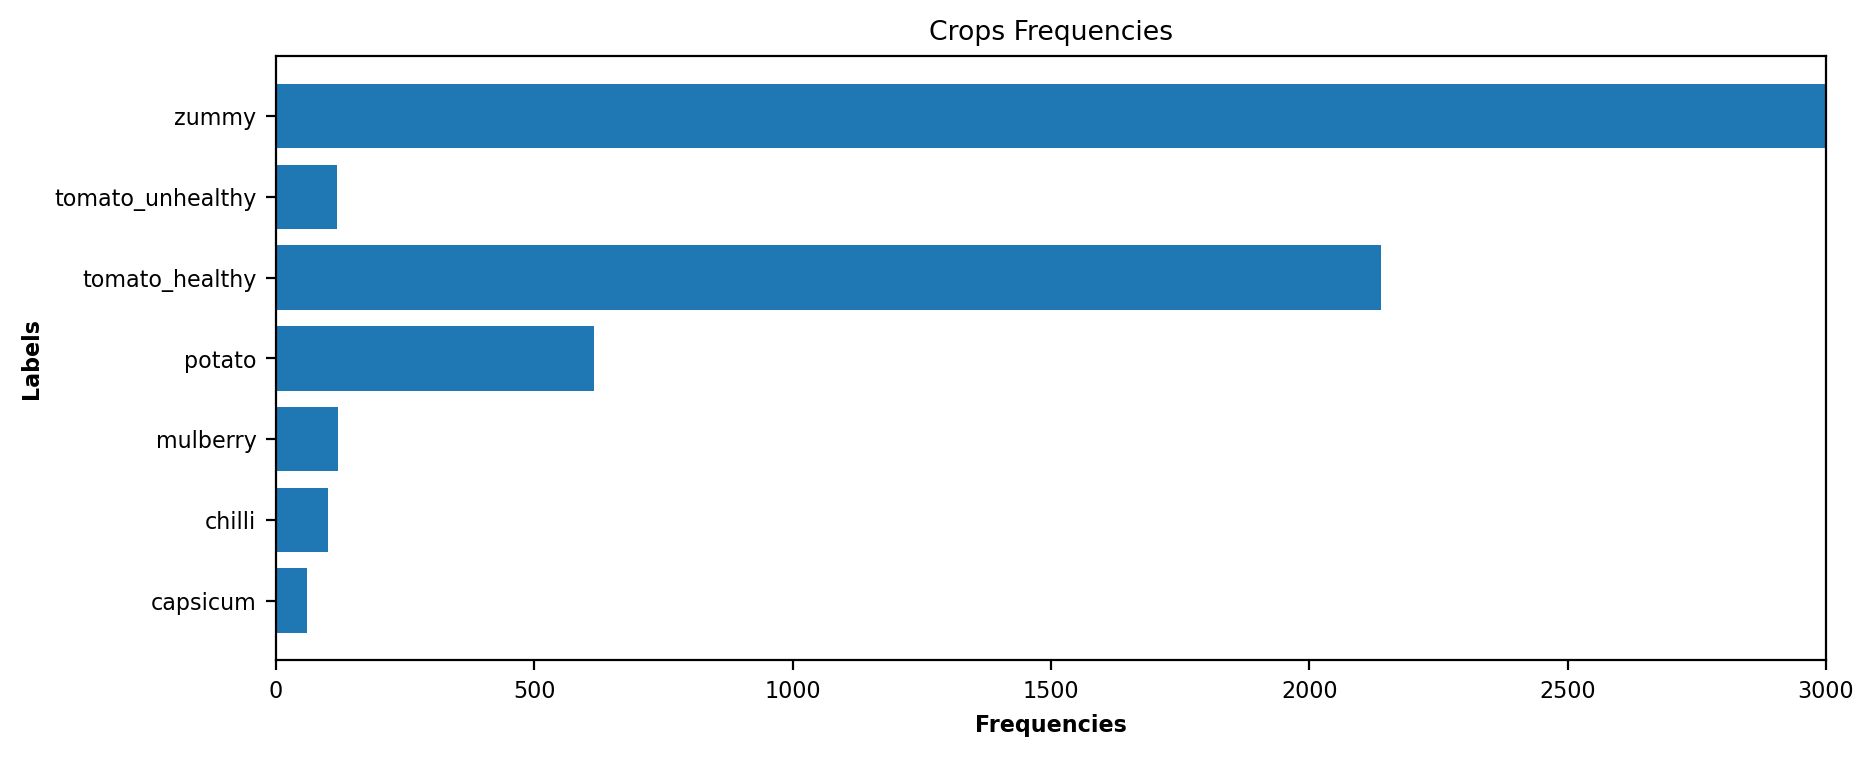

In [10]:
freq_visualize(df_final, title="Crops Frequencies")

In [11]:
# Generating X,y
X = df_final.drop("label",axis = 1)
y = df_final["label"]
print(X.shape, y.shape)

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(class_mapping)

(6825, 943) (6825,)
{'capsicum': 0, 'chilli': 1, 'mulberry': 2, 'potato': 3, 'tomato_healthy': 4, 'tomato_unhealthy': 5, 'zummy': 6}


In [13]:
# Applying SMOTE

target_per_class = 2000

sampling_strategy = {
    label: df_final['label'].value_counts()[label] + target_per_class
    for label in df_final['label'].unique()
}

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)

X_resampled, y_resampled = smote.fit_resample(X,y)
X_resampled.shape

C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\imblearn\utils\_validation.py:326: UserWarning:

After over-sampling, the number of samples (4138) in class tomato_healthy will be larger than the number of samples in the majority class (class #zummy -> 3672)

C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\imblearn\utils\_validation.py:326: UserWarning:

After over-sampling, the number of samples (5672) in class zummy will be larger than the number of samples in the majority class (class #zummy -> 3672)



(20825, 943)

In [14]:
X_resampled

,400,401,402,403,404,405,406,407,408,409,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,0.107553,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,0.110195,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,0.108327,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,0.111627,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,0.115504,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20820,0.087268,0.086462,0.084459,0.085418,0.085954,0.087330,0.090987,0.095927,0.089865,0.087913,...,0.442787,0.440309,0.439170,0.440359,0.439860,0.438369,0.436998,0.435265,0.434405,0.433354
20821,0.092172,0.091900,0.094254,0.096863,0.095011,0.089435,0.088480,0.096704,0.096967,0.096117,...,0.421581,0.417537,0.415535,0.415550,0.414317,0.412541,0.411228,0.410342,0.408814,0.406377
20822,0.139920,0.143473,0.144019,0.140661,0.138453,0.138667,0.139312,0.138412,0.138833,0.137175,...,0.315994,0.315817,0.314985,0.314617,0.314280,0.312798,0.312160,0.313289,0.312684,0.309935
20823,0.144637,0.147000,0.148709,0.147365,0.146833,0.145516,0.146398,0.150289,0.144954,0.141220,...,0.291222,0.290020,0.288995,0.288225,0.287504,0.286086,0.285254,0.284822,0.284918,0.286513


In [15]:
# adding label and columns

resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
resampled_df.insert(0, "label", y_resampled)
resampled_df

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,tomato_healthy,0.101378,0.101725,0.102485,0.103459,0.103914,0.104182,0.104880,0.106231,0.106578,...,0.547242,0.544077,0.541664,0.540310,0.538069,0.535569,0.534211,0.533388,0.531325,0.529307
1,tomato_healthy,0.103541,0.104723,0.105924,0.106492,0.106169,0.106725,0.107644,0.108090,0.108615,...,0.554549,0.550303,0.548048,0.545627,0.543121,0.542472,0.541165,0.537841,0.535955,0.536079
2,tomato_healthy,0.101660,0.102775,0.103691,0.103537,0.103872,0.105178,0.106558,0.107100,0.107503,...,0.532746,0.532024,0.530870,0.530600,0.527230,0.521051,0.519603,0.518942,0.516181,0.517180
3,tomato_healthy,0.104160,0.104660,0.105283,0.105518,0.106856,0.107884,0.108616,0.109425,0.110431,...,0.547227,0.543959,0.541547,0.539848,0.537445,0.535213,0.533859,0.532397,0.530679,0.530671
4,tomato_healthy,0.108282,0.109035,0.109674,0.109714,0.110377,0.111599,0.112497,0.112645,0.114480,...,0.559977,0.558477,0.555953,0.555026,0.552683,0.547314,0.546083,0.548683,0.547648,0.547143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20820,zummy,0.087268,0.086462,0.084459,0.085418,0.085954,0.087330,0.090987,0.095927,0.089865,...,0.442787,0.440309,0.439170,0.440359,0.439860,0.438369,0.436998,0.435265,0.434405,0.433354
20821,zummy,0.092172,0.091900,0.094254,0.096863,0.095011,0.089435,0.088480,0.096704,0.096967,...,0.421581,0.417537,0.415535,0.415550,0.414317,0.412541,0.411228,0.410342,0.408814,0.406377
20822,zummy,0.139920,0.143473,0.144019,0.140661,0.138453,0.138667,0.139312,0.138412,0.138833,...,0.315994,0.315817,0.314985,0.314617,0.314280,0.312798,0.312160,0.313289,0.312684,0.309935
20823,zummy,0.144637,0.147000,0.148709,0.147365,0.146833,0.145516,0.146398,0.150289,0.144954,...,0.291222,0.290020,0.288995,0.288225,0.287504,0.286086,0.285254,0.284822,0.284918,0.286513


zummy               5672
tomato_healthy      4138
potato              2616
mulberry            2120
tomato_unhealthy    2119
chilli              2100
capsicum            2060
Name: label, dtype: int64


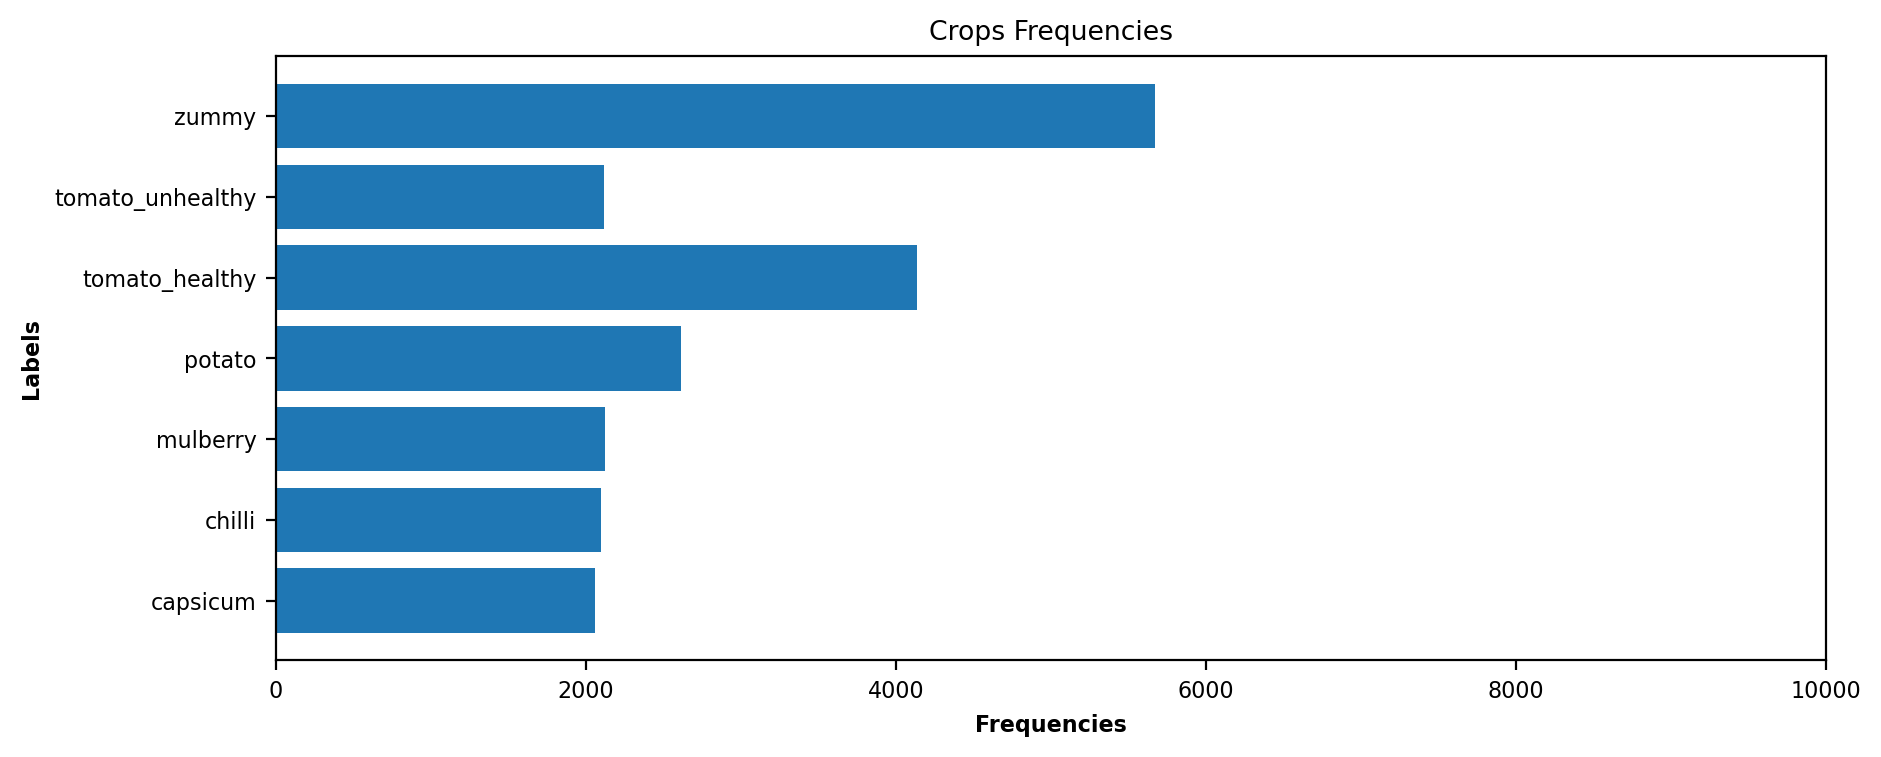

In [16]:
freq_visualize(resampled_df, title="Crops Frequencies", xlim=10000)

In [17]:
# Removing original samples from df | only SMOTE gen data will be remianed

resampled_df = resampled_df.iloc[len(df_final):].copy() # remove df_final length data from satrt
print(resampled_df.shape)

# group by crops
resampled_df.groupby(resampled_df.columns[0])

# crop and their count
print(resampled_df.iloc[:, 0].value_counts())

print("resampled_df.shape:", resampled_df.shape)
print("df_final.shape:", df_final.shape)

# Shuffeling

resampled_df = resampled_df.sample(frac = 1, random_state=None).reset_index(drop=True)
resampled_df = resampled_df.sample(frac = 1, random_state=None).reset_index(drop=True)

# removing NaN, inf, and -inf values
resampled_df = resampled_df[~resampled_df.isin([np.nan, np.inf, -np.inf]).any(axis = 1)]

resampled_df

(14000, 944)
zummy               2000
chilli              2000
potato              2000
tomato_healthy      2000
capsicum            2000
tomato_unhealthy    2000
mulberry            2000
Name: label, dtype: int64
resampled_df.shape: (14000, 944)
df_final.shape: (6825, 944)


,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
0,chilli,0.108872,0.104992,0.107223,0.112005,0.108184,0.107637,0.108430,0.106847,0.107795,...,0.558876,0.555527,0.554217,0.554055,0.552736,0.551955,0.550662,0.547289,0.545980,0.546016
1,tomato_healthy,0.088500,0.087610,0.085352,0.086237,0.086792,0.088374,0.092185,0.097000,0.090557,...,0.443000,0.440496,0.439353,0.440658,0.440225,0.438755,0.437371,0.435701,0.434818,0.433472
2,chilli,0.125722,0.127551,0.127410,0.123905,0.122053,0.123959,0.125898,0.124509,0.125062,...,0.576223,0.574173,0.572441,0.570469,0.569399,0.569942,0.568884,0.567103,0.565854,0.563027
3,tomato_unhealthy,0.081535,0.086265,0.085330,0.080980,0.083554,0.085890,0.087555,0.089035,0.086910,...,0.529081,0.528427,0.525866,0.523323,0.521282,0.517687,0.516229,0.517458,0.517154,0.517590
4,tomato_healthy,0.048141,0.052747,0.050815,0.045397,0.045186,0.044487,0.044292,0.046000,0.045520,...,0.299783,0.298522,0.297368,0.296173,0.294782,0.293706,0.292589,0.290664,0.289379,0.288489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,mulberry,0.068514,0.070373,0.069485,0.066883,0.065066,0.065038,0.067296,0.070549,0.067867,...,0.505741,0.504489,0.502434,0.499145,0.497438,0.497335,0.495484,0.492409,0.491238,0.490179
13996,capsicum,0.073328,0.073601,0.071916,0.070327,0.079041,0.078761,0.074331,0.074141,0.071963,...,0.384558,0.382025,0.380492,0.378709,0.377350,0.377567,0.376898,0.375236,0.374132,0.373575
13997,tomato_unhealthy,0.085289,0.082823,0.083437,0.086720,0.084720,0.084187,0.084480,0.083933,0.086294,...,0.540949,0.537190,0.534506,0.531418,0.529466,0.529405,0.527976,0.526193,0.524432,0.521321
13998,capsicum,0.118210,0.118415,0.117840,0.116665,0.121247,0.120407,0.117263,0.117160,0.117349,...,0.557467,0.555767,0.553379,0.549446,0.547207,0.545856,0.544328,0.543528,0.541803,0.539010


zummy               2000
chilli              2000
potato              2000
tomato_healthy      2000
capsicum            2000
tomato_unhealthy    2000
mulberry            2000
Name: label, dtype: int64


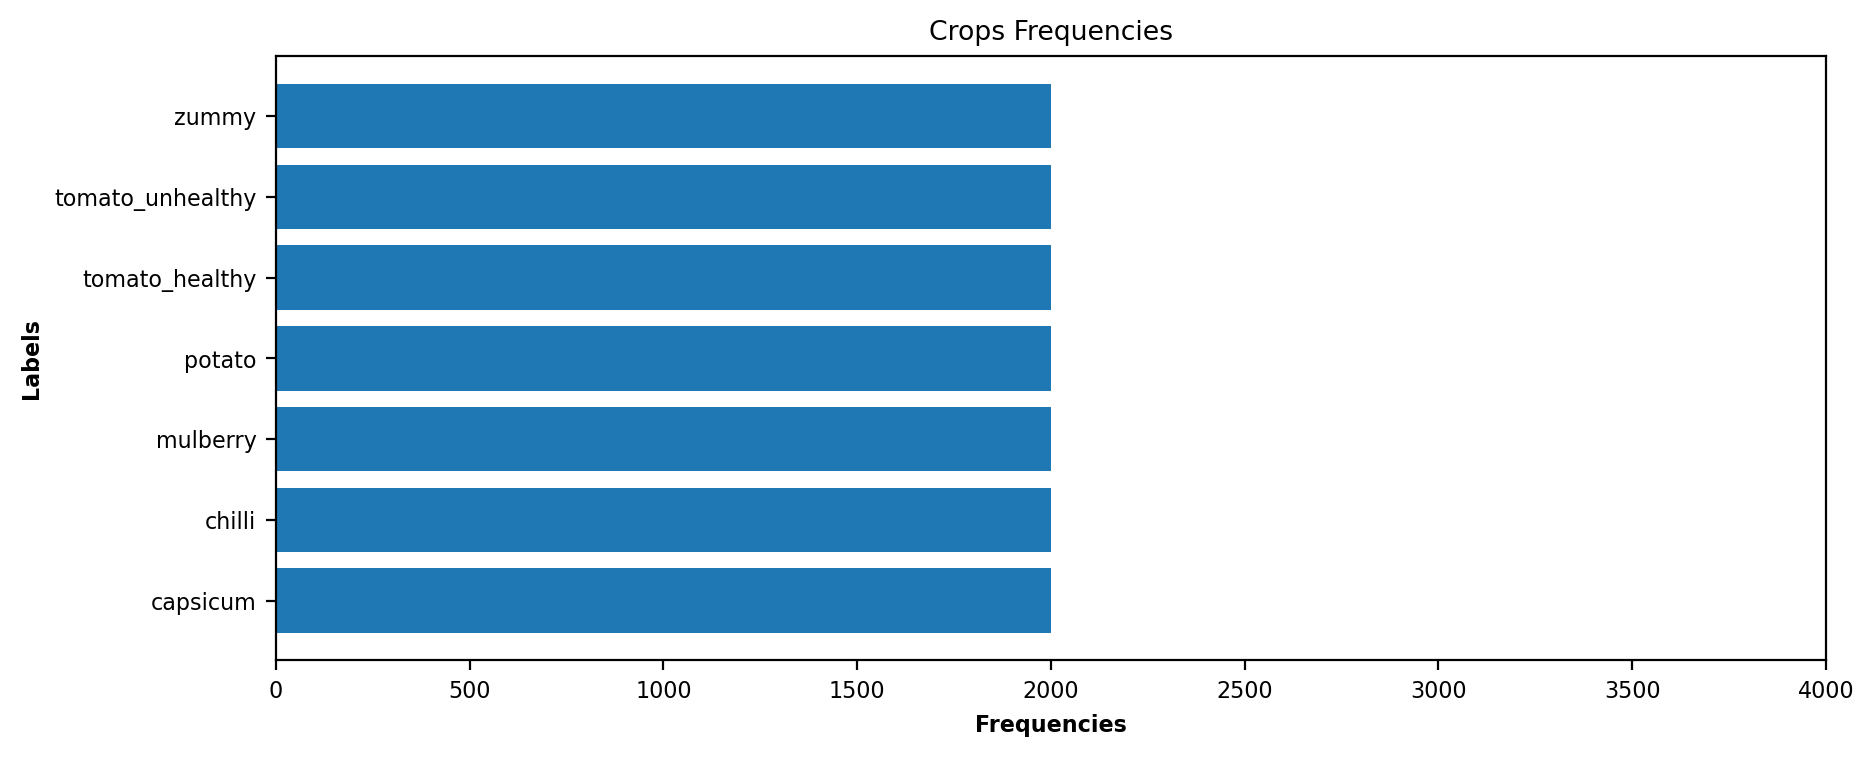

In [18]:
freq_visualize(resampled_df, title="Crops Frequencies", xlim=4000)

In [19]:
# Taking individual crops data out
tomato_healthy   = resampled_df.loc[resampled_df['label']=='tomato_healthy']
tomato_unhealthy = resampled_df.loc[resampled_df['label']=='tomato_unhealthy']
chilli           = resampled_df.loc[resampled_df['label']=='chilli']
potato           = resampled_df.loc[resampled_df['label']=='potato']
capsicum         = resampled_df.loc[resampled_df['label']=='capsicum']
mulberry         = resampled_df.loc[resampled_df['label']=='mulberry']

# Ensuring unique values
print(np.unique(tomato_healthy['label']))
print(np.unique(tomato_unhealthy['label']))
print(np.unique(chilli['label']))
print(np.unique(potato['label']))
print(np.unique(capsicum['label']))
print(np.unique(mulberry['label']))

['tomato_healthy']
['tomato_unhealthy']
['chilli']
['potato']
['capsicum']
['mulberry']


In [20]:
# Saving the data in excel format
tomato_healthy.to_excel(r"..\..\Data\4.SMOTE\tomato_healthy.xlsx", index=False)
tomato_unhealthy.to_excel(r"..\..\Data\4.SMOTE\tomato_unhealthy.xlsx", index=False)
capsicum.to_excel(r"..\..\Data\4.SMOTE\capsicum.xlsx", index=False)
chilli.to_excel(r"..\..\Data\4.SMOTE\chilli.xlsx", index=False)
potato.to_excel(r"..\..\Data\4.SMOTE\potato.xlsx", index=False)
mulberry.to_excel(r"..\..\Data\4.SMOTE\mulberry.xlsx", index=False)

In [21]:
# Saving the data in parquet format
import pandas as pd
from pathlib import Path

base_path = Path(r"..\..\Data\4.SMOTE")

# Ensure directory exists
base_path.mkdir(parents=True, exist_ok=True)

# Save to Parquet
tomato_healthy.to_parquet(base_path / "tomato_healthy.parquet", index=False)
tomato_unhealthy.to_parquet(base_path / "tomato_unhealthy.parquet", index=False)
capsicum.to_parquet(base_path / "capsicum.parquet", index=False)
chilli.to_parquet(base_path / "chilli.parquet", index=False)
potato.to_parquet(base_path / "potato.parquet", index=False)
mulberry.to_parquet(base_path / "mulberry.parquet", index=False)

# Ploting real and Syn data in 3D

In [22]:
from common_fun import create_data, apply_pca, apply_TSNE, apply_UMAP, plot_3D, plot_3D_static

mulberry real data shape: (120, 944)
mulberry synthetic data shape: (2000, 944)


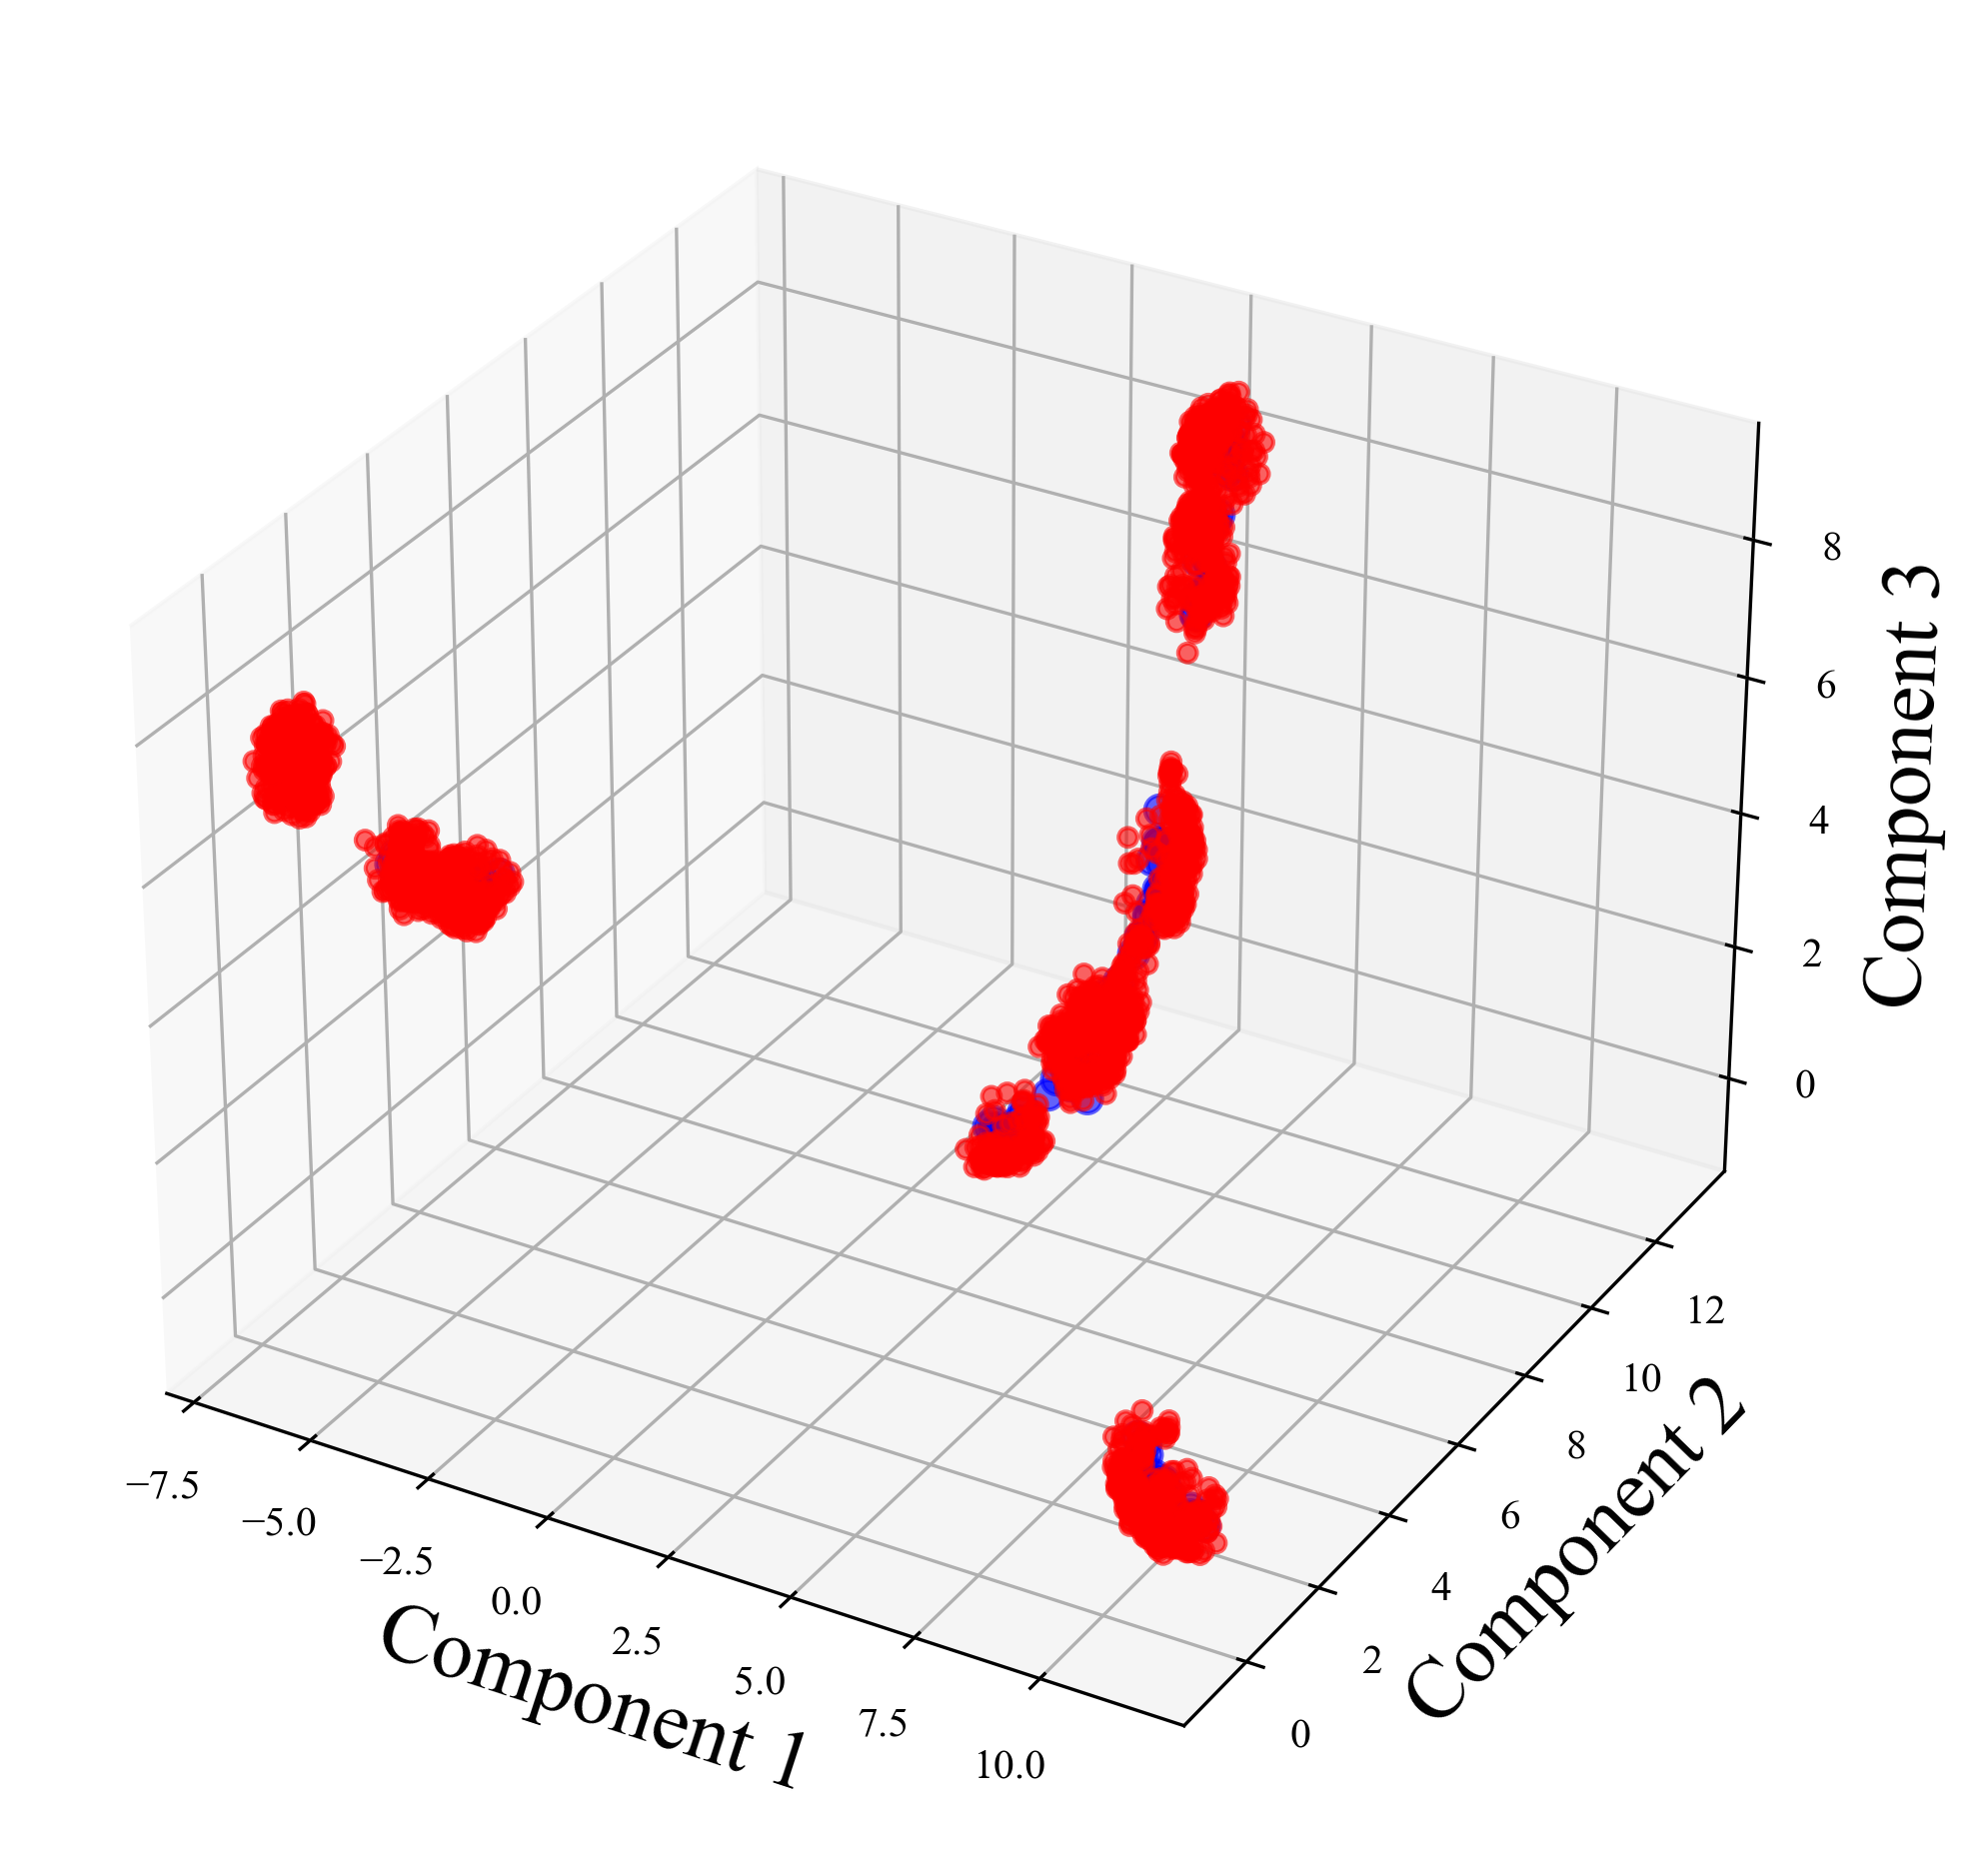

In [23]:
# tomato_healthy, tomato_unhealthy, chilli, potato, capsicum, mulberry
crop_name = "mulberry" #chilli, tomato_healthy, tomato_unhealthy, potato, capsicum, mulberry, 
X_real_scaled, X_synthetic_scaled = create_data(crop_name, df_final, resampled_df)

# plot_df = apply_pca(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="PCA")

# plot_df = apply_TSNE(X_real_scaled, X_synthetic_scaled)
# plot_3D(crop_name, plot_df, ptype="TSNE")

plot_df = apply_UMAP(X_real_scaled, X_synthetic_scaled)
plot_3D_static(crop_name, plot_df, ptype="UMAP")

# KL Divergence of Real Vs Syn data

In [24]:
from KLdivergence import kl_divergence

Overall KL Divergence by crop:
                  Overall KL
tomato_healthy      0.043035
tomato_unhealthy    0.115510
chilli              0.184959
potato              0.069879
capsicum            0.270961
mulberry            0.139828


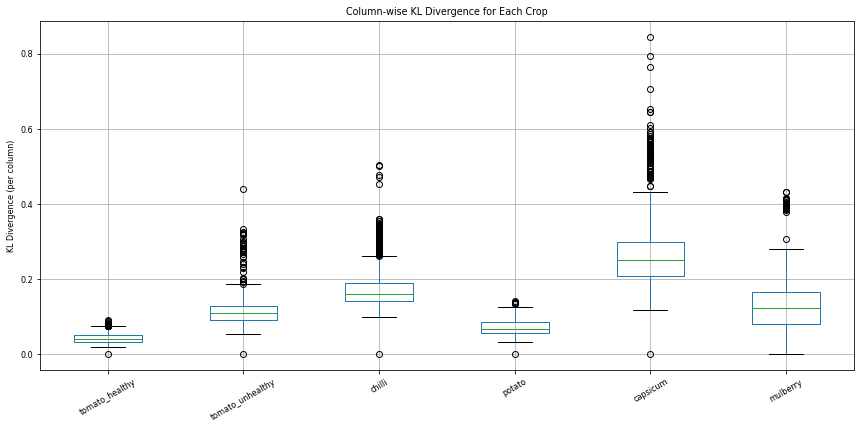

<Figure size 576x288 with 0 Axes>

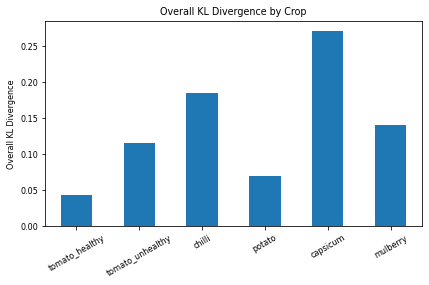

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

crop_names = ["tomato_healthy", "tomato_unhealthy", "chilli", "potato", "capsicum", "mulberry"]

# Store results for all crops
all_kl_scores = {}
overall_kl = {}

for crop in crop_names:
    real = df_final[df_final['label'] == crop]
    synth = resampled_df[resampled_df['label'] == crop]
    overall, kl_scores = kl_divergence(real, synth)
    all_kl_scores[crop] = kl_scores
    overall_kl[crop] = overall

# Convert overall KL to DataFrame for nice display
overall_kl_df = pd.DataFrame.from_dict(overall_kl, orient='index', columns=['Overall KL'])

print("Overall KL Divergence by crop:")
print(overall_kl_df)

# --- Plotting ---

# Plot per-column KL divergence (boxplot for each crop)
plt.figure(figsize=(12, 6))
kl_scores_df = pd.DataFrame(all_kl_scores)
kl_scores_df.boxplot()
plt.ylabel("KL Divergence (per column)")
plt.title("Column-wise KL Divergence for Each Crop")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Plot overall KL divergence bar plot
plt.figure(figsize=(8, 4))
overall_kl_df.plot(kind='bar', legend=False)
plt.ylabel("Overall KL Divergence")
plt.title("Overall KL Divergence by Crop")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()